# Helpers

In [1]:
import json
import re
import random
import statistics
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
_RUN_RE = re.compile(
    r"llama_drop_only_(?P<month>adzuna_month\d{2})_(?P<start>\d+)_(?P<stop>\d+)_job(?P<jobid>\d+)_task(?P<taskid>\d+)_\d{8}_\d{6}\.jsonl$"
)

IT_PATTERNS = [
    r"\bsoftware\b", r"\bdeveloper\b", r"\bengineer\b", r"\bdata\b", r"\bml\b", r"\bai\b",
    r"\bcloud\b", r"\bcyber\b", r"\bsecurity\b", r"\bnetwork\b", r"\bsystems?\b",
    r"\bdatabase\b", r"\bit\b", r"\bdevops\b"
]
_IT_RE = re.compile("|".join(IT_PATTERNS), flags=re.I)

def _is_it_role(title: str) -> bool:
    if not title:
        return False
    return bool(_IT_RE.search(title))


def _infer_npz_from_jsonl(jsonl_path: Path) -> Path:
    """
    NEW layout:
      .../llm_negative_selection/<EMBED>/<adzuna_monthXX>/llama_drop_only_....jsonl
    NPZ sits at:
      .../llm_negative_selection/<EMBED>/<adzuna_monthXX>.npz
    """
    m = _RUN_RE.search(jsonl_path.name)
    if not m:
        raise ValueError(f"JSONL filename doesn't match expected pattern: {jsonl_path.name}")

    month = m.group("month")
    embed_root = jsonl_path.parent.parent  # .../llm_negative_selection/<EMBED>
    return embed_root / f"{month}.npz"


def _get_job_ids(z) -> np.ndarray:
    """
    Supports both schemas:
      new: job_ids
      old: job_id
    Returns np.ndarray[str]
    """
    if "job_ids" in z.files:
        return z["job_ids"].astype(str)
    if "job_id" in z.files:
        return z["job_id"].astype(str)
    raise KeyError(f"NPZ missing job id key. Need job_ids or job_id. Have={sorted(z.files)}")


def _load_npz_lookup(npz_path: Path):
    """
    Expects stage3-prep NPZ keys (canonical):
      job_ids (or job_id), job_ad_title, job_desc, job_tasks, domain, job_sector_category, job_description
    """
    with np.load(npz_path, allow_pickle=True) as z:
        job_ids = _get_job_ids(z)

        # canonical (your stage3-prep)
        job_ad_title = z["job_ad_title"]
        job_desc = z["job_desc"]
        job_tasks = z["job_tasks"]

        domain = z["domain"] if "domain" in z.files else None
        job_sector_category = z["job_sector_category"] if "job_sector_category" in z.files else None
        job_description = z["job_description"] if "job_description" in z.files else None

    lookup = {}
    for i, jid in enumerate(job_ids):
        lookup[jid] = {
            "job_ad_title": None if job_ad_title[i] is None else str(job_ad_title[i]),
            "job_desc": None if job_desc[i] is None else str(job_desc[i]),
            "job_tasks": None if job_tasks[i] is None else str(job_tasks[i]),
            "job_description": None if job_description is None or job_description[i] is None else str(job_description[i]),
            "domain": None if domain is None or domain[i] is None else str(domain[i]),
            "job_sector_category": None if job_sector_category is None or job_sector_category[i] is None else str(job_sector_category[i]),
        }
    return lookup


# ---------------------------------------------------------------------
# Main: report generator
# ---------------------------------------------------------------------
def gen_report(jsonl_path: str, *, npz_path: str | None = None, sample_n: int = 30, seed: int = 0):
    """
    jsonl_path: path to llama_drop_only_*.jsonl
    npz_path  : optional explicit context NPZ. If None, inferred from jsonl name/dir.
    """
    random.seed(seed)

    jsonl_path = Path(jsonl_path)
    if not jsonl_path.exists():
        raise FileNotFoundError(f"Missing JSONL: {jsonl_path}")

    inferred_npz = _infer_npz_from_jsonl(jsonl_path)
    npz_path = Path(npz_path) if npz_path else inferred_npz
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing NPZ: {npz_path}")

    # report folder: put it under .../llm_negative_selection/<EMBED>/evaluation_reports/
    embed_root = jsonl_path.parent.parent  # .../llm_negative_selection/<EMBED>
    report_dir = embed_root / "evaluation_reports"
    report_dir.mkdir(parents=True, exist_ok=True)

    print("JSONL:", jsonl_path)
    print("NPZ :", npz_path)
    print("OUT :", report_dir)

    lookup = _load_npz_lookup(npz_path)

    before_counts = []
    after_counts = []
    kept_titles = Counter()
    domain_kept = defaultdict(list)

    it_leak = 0
    total_kept = 0
    empty_outputs = 0

    samples = []
    seen_sample_ids = set()

    with jsonl_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                r = json.loads(line)
            except Exception:
                continue

            jid = str(r.get("job_id", "")).strip()
            if not jid:
                continue

            ctx = lookup.get(jid, {})

            cand = r.get("candidates") or []
            final = r.get("final") or []

            before_counts.append(len(cand))
            after_counts.append(len(final))

            if len(final) == 0:
                empty_outputs += 1

            for t in final:
                kept_titles[t] += 1
                total_kept += 1
                if _is_it_role(t):
                    it_leak += 1

            dom = ctx.get("domain") or "UNKNOWN"
            domain_kept[dom].append(len(final))

            # sample gate
            if len(samples) < sample_n and jid not in seen_sample_ids and random.random() < 0.05:
                seen_sample_ids.add(jid)
                samples.append({
                    "job_id": jid,
                    "job_ad_title": ctx.get("job_ad_title"),
                    "domain": ctx.get("domain"),
                    "sector": ctx.get("job_sector_category"),
                    "job_desc": ctx.get("job_desc"),
                    "kept": final,
                    "dropped": r.get("drop") or [],
                })

    if not before_counts:
        raise RuntimeError("No valid rows parsed from JSONL.")

    before_avg = statistics.mean(before_counts)
    after_avg = statistics.mean(after_counts)
    drop_rate = 1.0 - (after_avg / before_avg if before_avg else 0.0)
    it_share = it_leak / max(total_kept, 1)

    metrics = {
        "jobs": len(before_counts),
        "avg_candidates_before": round(before_avg, 3),
        "avg_candidates_after": round(after_avg, 3),
        "drop_rate": round(drop_rate, 4),
        "empty_outputs_percent": round(100.0 * empty_outputs / len(before_counts), 3),
        "it_leakage_share": round(it_share, 4),
        "min_kept": int(min(after_counts)),
        "max_kept": int(max(after_counts)),
    }

    domain_summary = {d: round(statistics.mean(v), 3) for d, v in domain_kept.items()}

    report = {
        "run": {
            "jsonl": str(jsonl_path),
            "npz": str(npz_path),
            "generated_at": datetime.now().isoformat(timespec="seconds"),
        },
        "global_metrics": metrics,
        "top_kept_roles": kept_titles.most_common(25),
        "domain_summary_avg_kept": dict(sorted(domain_summary.items(), key=lambda x: (-x[1], x[0]))),
        "sample_cases": samples,
    }

    base = jsonl_path.stem
    report_json = report_dir / f"{base}_report.json"
    report_txt = report_dir / f"{base}_report.txt"

    with report_json.open("w", encoding="utf-8") as f:
        json.dump(report, f, indent=2, ensure_ascii=False)

    with report_txt.open("w", encoding="utf-8") as f:
        f.write("=== GLOBAL METRICS ===\n")
        for k, v in metrics.items():
            f.write(f"{k}: {v}\n")

        f.write("\n=== TOP KEPT OCCUPATIONS ===\n")
        for title, cnt in kept_titles.most_common(25):
            f.write(f"{cnt}  {title}\n")

        f.write("\n=== DOMAIN AVG KEPT ===\n")
        for d, v in sorted(domain_summary.items(), key=lambda x: (-x[1], x[0])):
            f.write(f"{d}: {v}\n")

        f.write("\n=== SAMPLE CASES (truncated) ===\n")
        for s in samples[:10]:
            f.write(f"\njob_id: {s['job_id']}\n")
            f.write(f"title:  {s.get('job_ad_title')}\n")
            f.write(f"domain: {s.get('domain')} | sector: {s.get('sector')}\n")
            f.write(f"kept:   {s.get('kept')}\n")
            f.write(f"drop:   {s.get('dropped')}\n")

    print("\nSaved:")
    print(" ", report_json)
    print(" ", report_txt)

    return report_json, report_txt


# Prompt 4 - A bit less strict than prompt 3

In [2]:
 # ===== Prompt printer: OCCUPATION MATCHER (E5 Production) =====

import numpy as np
from pathlib import Path

# ---- CONFIG ----
NPZ_PATH = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01.npz")
ROW_IDX = 35  # Inspect any sample row

# ---- LOAD ----
data = np.load(NPZ_PATH, allow_pickle=True)

# Map NPZ keys to variables
title = data["job_ad_title"][ROW_IDX]
domain = data["domain"][ROW_IDX]
category = data["job_sector_category"][ROW_IDX]
desc = data["job_desc"][ROW_IDX]
tasks = data["job_tasks"][ROW_IDX]
full_excerpt = data["job_description"][ROW_IDX]
row_candidates = data["titles"][ROW_IDX]

# Clean up tasks string
if isinstance(tasks, (list, np.ndarray)):
    tasks_str = ", ".join([str(t) for t in tasks if t])
else:
    tasks_str = str(tasks)

# Format candidates as a 1-based numbered list
numbered_candidates = "\n".join([f"{i+1}) {cand}" for i, cand in enumerate(row_candidates) if cand])

# ---- BUILD PROMPT (Verbatim Production Version) ----

full_block = (
    f"\nFULL AD EXCERPT:\n{str(full_excerpt)[:700]}\n"
    if full_excerpt else ""
)

prompt = f"""You are an Occupation Matcher. Your job is to DROP candidates that do NOT fit the job.
Default outcome: keep ONE best match. Keep 2–3 only if tasks clearly show distinct roles (not synonyms).

JOB CONTEXT
Title: {title}
Domain: {domain}
Category: {category}
Short Desc: {desc}
Tasks/Skills: {tasks_str}
{full_block}

CANDIDATES (1-based)
{numbered_candidates}

RE-READ ANCHOR JOB CONTEXT:
Title: {title}
Domain: {domain}
Tasks/Skills: {tasks_str}

DECISION GUIDELINES
1) Anchor first: prefer the candidate that most directly matches the job title, unless tasks clearly contradict it.
2) Specificity: if both a specialist and a generic parent are present, keep the specialist and drop the generic.
3) Primary role bias: keep one candidate unless tasks prove truly multi-functional work.
4) Non-IT domains: drop Software/Data roles unless there is explicit evidence of building software (coding, pipelines, systems, APIs, models). Using tools (Excel, CRM, SAP) is not enough.
5) Max kept: never keep more than 3.

OUTPUT FORMAT
Return ONLY valid JSON with exactly this key:
{{"drop":[...]}}
""".strip()

# ---- PRINT ----
print("-" * 30)
print(f"VERIFIED PRODUCTION PROMPT (ROW {ROW_IDX}):")
print("-" * 30)
print(prompt)
print("-" * 30)

------------------------------
VERIFIED PRODUCTION PROMPT (ROW 35):
------------------------------
You are an Occupation Matcher. Your job is to DROP candidates that do NOT fit the job.
Default outcome: keep ONE best match. Keep 2–3 only if tasks clearly show distinct roles (not synonyms).

JOB CONTEXT
Title: Sommelier-Restaurant Gordon Ramsay
Domain: Hospitality & Catering
Category: Hospitality & Catering Jobs
Short Desc: [Hospitality & Catering] Sommelier for a Three Michelin Star restaurant
Tasks/Skills: [Hospitality & Catering] Assist the Head Sommelier with wine and beverage service Supervise setting up and clearing down after each service Recommend and sell wines to guests Engage with customers to deliver high levels of service Supervise wine and beverage service WSET certification Wine knowledge Customer service Communication Leadership

FULL AD EXCERPT:
Sommelier - Restaurant Gordon Ramsay, Three Michelin Star We are looking for an experienced Sommelier who has a real passion f

## bge

In [3]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_bge.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)
bge_jobid = jobid

JOBID: 2166745


## e5

In [4]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_e5.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)
e5_jobid = jobid

JOBID: 2166746


## gte

In [5]:
import subprocess, re
from pathlib import Path

SBATCH = Path("/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drop_gte.sbatch")
assert SBATCH.exists(), f"Missing sbatch file: {SBATCH}"

out = subprocess.check_output(["sbatch", str(SBATCH)], text=True)
jobid = re.search(r"(\d+)", out).group(1)
print("JOBID:", jobid)
gte_jobid = jobid

JOBID: 2166747


In [6]:
# monitoring

In [7]:
import time, subprocess
from pathlib import Path

LOG_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/logs")
def sh(cmd):
    return subprocess.run(cmd, shell=True, text=True, capture_output=True).stdout.strip()
while True:
    print("\n=== squeue ===")
    sq = sh(f"squeue -j {jobid}")
    print(sq if sq else "<finished>")

    out_logs = sorted(LOG_DIR.glob(f"*{jobid}*.out"))
    err_logs = sorted(LOG_DIR.glob(f"*{jobid}*.err"))

    if out_logs:
        print("\n--- STDOUT ---")
        print(sh(f"tail -n 20 {out_logs[-1]}"))

    if err_logs:
        print("\n--- STDERR ---")
        print(sh(f"tail -n 20 {err_logs[-1]}"))

    if not sq:
        break

    time.sleep(5)



=== squeue ===
JOBID         USER PARTITION                     NAME ST TIME_LIMIT       TIME  TIME_LEFT NODES NODELIST(REASON)
2166747 autonomyluiz     workq z_llama_drop_new_test_gt PD    6:00:00       0:00    6:00:00     1 (None)

=== squeue ===
JOBID         USER PARTITION                     NAME ST TIME_LIMIT       TIME  TIME_LEFT NODES NODELIST(REASON)
2166747 autonomyluiz     workq z_llama_drop_new_test_gt  R    6:00:00       0:01    5:59:59     1 nid010596

--- STDOUT ---
PROJECT=/projects/a5u/adu_dev/aisi-economy-index
BASE=/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev
SCRIPT=/projects/a5u/adu_dev/aisi-economy-index/nbs/AISI_demo/Stage_3_negative_selection/dev/sbatch/run_llama_drops_fix_test.py
NPZ_DIR=/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large
total 7,0M
drwxr-xr-x 2 autonomyluiz.a5u autonomyluiz.a5u 4,0K fev  5 13:10 adzuna_month01
-rw-r--r-- 1 autonomylu

KeyboardInterrupt: 

In [8]:
import time, subprocess
from pathlib import Path

for jobid in [bge_jobid, e5_jobid, gte_jobid]:
    LOG_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/logs")
    
    DONE_TAG = "DONE] wrote:"
    
    def sh(cmd: str) -> str:
        return subprocess.run(cmd, shell=True, text=True, capture_output=True).stdout
    
    def tail(path: Path, n: int = 80) -> str:
        return sh(f"tail -n {n} {path}")
    
    def latest_log(jobid: int, suffix: str) -> Path | None:
        logs = sorted(LOG_DIR.glob(f"*{jobid}*{suffix}"))
        return logs[-1] if logs else None
    
    seen = set()
    
    import time
    
    done_path = None
    
    while True:
        out_log = latest_log(jobid, ".out")
    
        if out_log and out_log.exists():
            chunk = tail(out_log, 120)
            for line in chunk.splitlines():
                if DONE_TAG in line:
                    done_path = line.split(DONE_TAG, 1)[1].strip()
                    print(f"[DONE] {done_path}")
                    break
    
            if done_path:
                break
    
        time.sleep(5)
    
    
    done_path
    print('**'*50)



[DONE] /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2166745_task0_20260205_162620.jsonl
****************************************************************************************************
[DONE] /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2166746_task0_20260205_162623.jsonl
****************************************************************************************************
[DONE] /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2166747_task0_20260205_162620.jsonl
****************************************************************************************************


## Results comparison


--- BGE ---
JSONL: /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2166745_task0_20260205_162620.jsonl
NPZ : /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01.npz
OUT : /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports

Saved:
  /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2166745_task0_20260205_162620_report.json
  /projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2166745_task0_20260205_162620_report.txt

--- E5 ---
JSONL:

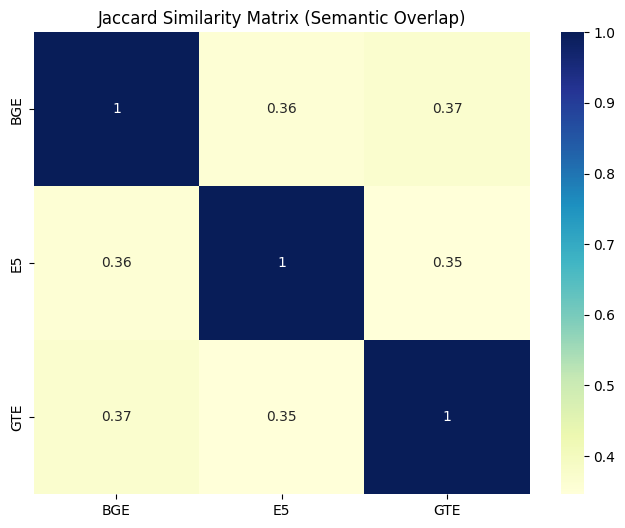

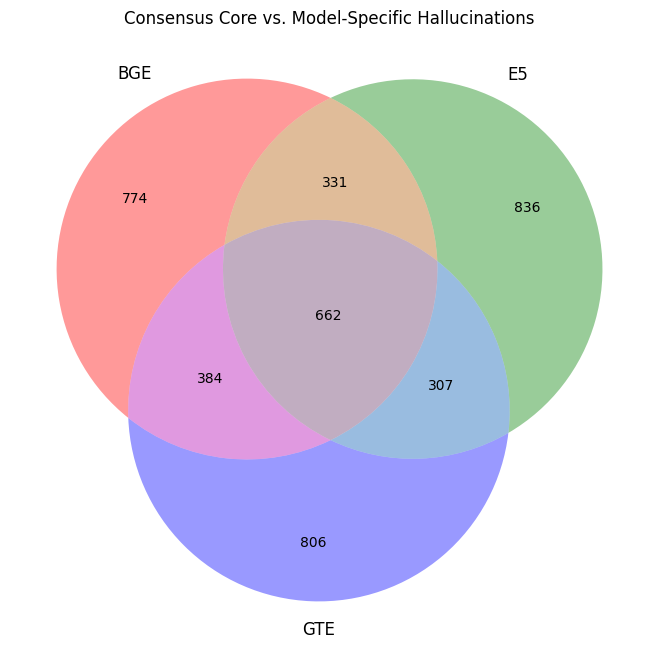

In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3
from pathlib import Path

# ---- CONFIG ----
BASE_DIR = Path("/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection")

# 1. Define once (Update these only)
PATHS = {
    "BGE": BASE_DIR / "bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2166745_task0_20260205_162620.jsonl",
    "E5":  BASE_DIR / "e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2166746_task0_20260205_162623.jsonl",
    "GTE": BASE_DIR / "gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2166747_task0_20260205_162620.jsonl"
}

# 2. Run reports automatically for each
for model_name, file_path in PATHS.items():
    print(f"\n--- {model_name} ---")
    if file_path.exists():
        gen_report(str(file_path))
    else:
        print(f"Error: File for {model_name} not found at {file_path}")
def load_data(filepath):
    data = {}
    if not filepath.exists(): return data
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            obj = json.loads(line)
            data[obj['job_id']] = set(obj['final'])
    return data

# 1. Load and Intersect
results = {name: load_data(path) for name, path in PATHS.items()}
loaded = [n for n, d in results.items() if d]
common_ids = set.intersection(*[set(results[m].keys()) for m in loaded])

# 2. Extract Commonalities and Differences
report_data = []
for jid in common_ids:
    bge_set = results["BGE"].get(jid, set())
    e5_set = results["E5"].get(jid, set())
    gte_set = results["GTE"].get(jid, set())
    
    # Are they identical?
    all_agree = (bge_set == e5_set == gte_set)
    
    # Who is the outlier?
    outlier = "None"
    if bge_set == e5_set != gte_set: outlier = "GTE"
    elif bge_set == gte_set != e5_set: outlier = "E5"
    elif e5_set == gte_set != bge_set: outlier = "BGE"
    elif not all_agree: outlier = "All Diverged"

    report_data.append({
        "job_id": jid,
        "all_agree": all_agree,
        "outlier": outlier,
        "bge_count": len(bge_set),
        "e5_count": len(e5_set),
        "gte_count": len(gte_set),
        "consensus_count": len(bge_set & e5_set & gte_set)
    })

df = pd.DataFrame(report_data)

# 3. Print Statistical Summary
print("=== COMPREHENSIVE COMPARISON REPORT ===")
print(f"Total Common Jobs: {len(df)}")
print(f"Absolute Consensus: {df['all_agree'].sum()} ({df['all_agree'].mean():.1%})")
print("\n--- Outlier Frequency (Who disagrees with the majority?) ---")
print(df[df['outlier'] != "None"]['outlier'].value_counts())

# 4. Generate Visualizations
# Jaccard Heatmap
model_names = list(results.keys())
j_matrix = np.zeros((3, 3))
for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        scores = [len(results[m1][jid] & results[m2][jid]) / len(results[m1][jid] | results[m2][jid]) 
                  for jid in common_ids]
        j_matrix[i, j] = np.mean(scores)

plt.figure(figsize=(8, 6))
sns.heatmap(j_matrix, annot=True, xticklabels=model_names, yticklabels=model_names, cmap="YlGnBu")
plt.title("Jaccard Similarity Matrix (Semantic Overlap)")
plt.savefig("semantic_overlap_heatmap.png")

# Venn Diagram
venn_sets = []
for name in model_names:
    s = set()
    for jid in common_ids:
        for occ in results[name][jid]:
            s.add(f"{jid}|{occ}")
    venn_sets.append(s)

plt.figure(figsize=(10, 8))
venn3(venn_sets, set_labels=model_names)
plt.title("Consensus Core vs. Model-Specific Hallucinations")
plt.savefig("assignment_venn.png")

In [10]:
from pathlib import Path

# 1. Define your specific report files once
REPORTS = {
    "BGE_LARGE": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2166745_task0_20260205_162620_report.txt",
    "E5_LARGE":  "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2166746_task0_20260205_162623_report.txt",
    "GTE_LARGE": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/evaluation_reports/llama_drop_only_adzuna_month01_0_1000_job2166747_task0_20260205_162620_report.txt"
}

# 2. Loop through and print with clear headers
for model_name, file_path in REPORTS.items():
    p = Path(file_path)
    
    # Visual Header for scannability
    print("\n" + "="*60)
    print(f"****** {model_name} ******")
    print("="*60)
    
    if p.exists():
        print(p.read_text())
    else:
        print(f"FILE NOT FOUND: {file_path}")


****** BGE_LARGE ******
=== GLOBAL METRICS ===
jobs: 1000
avg_candidates_before: 8.221
avg_candidates_after: 2.151
drop_rate: 0.7384
empty_outputs_percent: 0.0
it_leakage_share: 0.0702
min_kept: 1
max_kept: 3

=== TOP KEPT OCCUPATIONS ===
42  Information Technology Project Managers
35  Personal Care Aides
31  Customer Service Representatives
31  Software Developers
28  Financial Managers
24  Mental Health and Substance Abuse Social Workers
24  Sales Managers
23  Social and Human Service Assistants
20  Marketing Managers
20  Healthcare Social Workers
19  Chefs and Head Cooks
19  Accountants and Auditors
19  Sales Representatives, Wholesale and Manufacturing, Technical and Scientific Products
19  First-Line Supervisors of Retail Sales Workers
19  Computer Systems Engineers/Architects
19  Teaching Assistants, Special Education
19  Nursing Assistants
18  Advertising and Promotions Managers
18  Laborers and Freight, Stock, and Material Movers, Hand
18  Food Service Managers
17  Acute Care 

In [ ]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

# 1. EXACT CONFIGURATION
PATHS = {
    "BGE": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2161851_task0_20260205_130649.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01.npz",
    },
    "E5": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2161866_task0_20260205_131005.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01.npz",
    },
    "GTE": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2161867_task0_20260205_131005.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01.npz",
    },
}

# 2. HELPER FUNCTIONS
def _to_str_array(x: np.ndarray) -> np.ndarray:
    if x.dtype == object:
        return np.array([v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else str(v) for v in x])
    if np.issubdtype(x.dtype, np.bytes_):
        return np.array([v.decode("utf-8") for v in x])
    return x.astype(str)

def load_meta_from_npz(npz_path: str) -> pd.DataFrame:
    with np.load(npz_path, allow_pickle=True) as npz:
        job_id_key = "job_id" if "job_id" in npz.files else ("job_ids" if "job_ids" in npz.files else None)
        title_key = "job_ad_title" if "job_ad_title" in npz.files else ("title" if "title" in npz.files else None)
        domain_key = "domain" if "domain" in npz.files else None
        sector_key = "job_sector_category" if "job_sector_category" in npz.files else None

        meta = {
            "job_id": _to_str_array(npz[job_id_key]),
            "title": _to_str_array(npz[title_key]),
        }
        meta["domain"] = _to_str_array(npz[domain_key]) if domain_key else ""
        meta["sector"] = _to_str_array(npz[sector_key]) if sector_key else ""
    return pd.DataFrame(meta)

def load_results_from_jsonl(jsonl_path: str) -> pd.DataFrame:
    rows = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try: rows.append(json.loads(line))
            except: continue

    df = pd.DataFrame(rows)
    df["job_id"] = df["job_id"].astype(str)

    # Normalize fields (final -> kept | drop -> dropped)
    if "final" in df.columns: df = df.rename(columns={"final": "kept"})
    if "drop" in df.columns: df = df.rename(columns={"drop": "dropped"})
    
    if "kept" not in df.columns: df["kept"] = None
    if "dropped" not in df.columns: df["dropped"] = None

    def _list_to_csv(x):
        if isinstance(x, list): return ", ".join(map(str, x))
        return "" if x is None else str(x)

    df["kept"] = df["kept"].apply(_list_to_csv)
    df["dropped"] = df["dropped"].apply(_list_to_csv)
    return df[["job_id", "kept", "dropped"]]

# 3. CORE BUILDER
def build_audit_dataset(paths_by_model: dict, n_jobs_per_model: int = 100, seed: int = 42) -> pd.DataFrame:
    all_frames = []
    for model, p in paths_by_model.items():
        print(f"Lendo dados para {model}...")
        meta = load_meta_from_npz(p["npz"])
        res = load_results_from_jsonl(p["jsonl"])
        
        merged = res.merge(meta, on="job_id", how="inner")
        if merged.empty:
            print(f"!!! [AVISO] {model} resultou em merge vazio.")
            continue
            
        sample_size = min(n_jobs_per_model, len(merged))
        sampled = merged.sample(n=sample_size, random_state=seed).copy()
        sampled["model"] = model
        all_frames.append(sampled)

    out = pd.concat(all_frames, ignore_index=True)
    cols = ["job_id", "model", "title", "domain", "sector", "kept", "dropped"]
    for c in cols:
        if c not in out.columns: out[c] = ""
            
    return out[cols].sort_values(["model", "job_id"]).reset_index(drop=True)

# 4. EXECUTION
if __name__ == "__main__":
    # Fixed argument name to match the function definition
    audit_df = build_audit_dataset(PATHS, n_jobs_per_model=100, seed=42)
    
    out_path = Path("sanity_check_300_jobs_FINAL.csv")
    audit_df.to_csv(out_path, index=False)
    
    print("-" * 30)
    print(f"[SUCESSO] Arquivo escrito: {out_path}")
    print(f"Total de linhas: {len(audit_df)}")
    print(f"Distribuição por modelo:\n{audit_df['model'].value_counts()}")
    print("-" * 30)

In [ ]:
import pandas as pd

df = pd.read_csv("sanity_check_300_jobs_FINAL.csv")

# 1. Criar contador de itens mantidos
df['n_kept'] = df['kept'].str.split(',').apply(lambda x: len(x) if isinstance(x, list) else 0)

# 2. Filtrar domínios Non-IT (ignorando IT e Software Development)
it_domains = ['IT', 'Software Development', 'IT Jobs', 'IT and Technology']
non_it_df = df[~df['domain'].isin(it_domains)].copy()

# 3. Calcular a média de candidatos mantidos por modelo
contamination_report = non_it_df.groupby('model')['n_kept'].mean().sort_values()

print("--- MÉDIA DE CANDIDATOS EM DOMÍNIOS NON-IT ---")
print("(Quanto menor, mais limpo é o índice)")
print(contamination_report)
print("-" * 45)

# 4. Verificar o "Custo da Ambiguidade" (Frequência de Kept > 1)
multi_match = non_it_df[non_it_df['n_kept'] > 1].groupby('model').size() / non_it_df.groupby('model').size()
print("\n--- TAXA DE MULTI-MATCH (HEDGING) ---")
print(multi_match.sort_values())

In [12]:
notebook_name = "state_of_art_04_abit_less_stricter_intermed_prompt_sbatch_llm_negsel_per_embed_V2"

In [13]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd

# 1. EXACT CONFIGURATION
PATHS = {
    "BGE": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2166745_task0_20260205_162620.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/bge_large/adzuna_month01.npz",
    },
    "E5": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2166746_task0_20260205_162623.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/e5_large/adzuna_month01.npz",
    },
    "GTE": {
        "jsonl": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01/llama_drop_only_adzuna_month01_0_1000_job2166747_task0_20260205_162620.jsonl",
        "npz": "/projects/a5u/adu_dev/aisi-economy-index/aisi_economy_index/store/AISI_demo/stage_3/dev/llm_negative_selection/gte_large/adzuna_month01.npz",
    },
}

# 2. HELPER FUNCTIONS
def _to_str_array(x: np.ndarray) -> np.ndarray:
    if x.dtype == object:
        return np.array([v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else str(v) for v in x])
    if np.issubdtype(x.dtype, np.bytes_):
        return np.array([v.decode("utf-8") for v in x])
    return x.astype(str)

def load_meta_from_npz(npz_path: str) -> pd.DataFrame:
    with np.load(npz_path, allow_pickle=True) as npz:
        job_id_key = "job_id" if "job_id" in npz.files else ("job_ids" if "job_ids" in npz.files else None)
        title_key = "job_ad_title" if "job_ad_title" in npz.files else ("title" if "title" in npz.files else None)
        domain_key = "domain" if "domain" in npz.files else None
        sector_key = "job_sector_category" if "job_sector_category" in npz.files else None

        meta = {
            "job_id": _to_str_array(npz[job_id_key]),
            "title": _to_str_array(npz[title_key]),
        }
        meta["domain"] = _to_str_array(npz[domain_key]) if domain_key else ""
        meta["sector"] = _to_str_array(npz[sector_key]) if sector_key else ""
    return pd.DataFrame(meta)

def load_results_from_jsonl(jsonl_path: str) -> pd.DataFrame:
    rows = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try: rows.append(json.loads(line))
            except: continue

    df = pd.DataFrame(rows)
    df["job_id"] = df["job_id"].astype(str)

    if "final" in df.columns: df = df.rename(columns={"final": "kept"})
    if "drop" in df.columns: df = df.rename(columns={"drop": "dropped"})
    
    if "kept" not in df.columns: df["kept"] = None
    if "dropped" not in df.columns: df["dropped"] = None

    def _list_to_csv(x):
        if isinstance(x, list): return ", ".join(map(str, x))
        return "" if x is None else str(x)

    df["kept"] = df["kept"].apply(_list_to_csv)
    df["dropped"] = df["dropped"].apply(_list_to_csv)
    return df[["job_id", "kept", "dropped"]]

# 3. CORE BUILDER
def build_audit_dataset(paths_by_model: dict, n_jobs_per_model: int = 100, seed: int = 42) -> pd.DataFrame:
    all_frames = []
    for model, p in paths_by_model.items():
        print(f"Lendo dados para {model}...")
        meta = load_meta_from_npz(p["npz"])
        res = load_results_from_jsonl(p["jsonl"])
        
        merged = res.merge(meta, on="job_id", how="inner")
        if merged.empty:
            print(f"!!! [AVISO] {model} resultou em merge vazio.")
            continue
            
        sample_size = min(n_jobs_per_model, len(merged))
        sampled = merged.sample(n=sample_size, random_state=seed).copy()
        sampled["model"] = model
        all_frames.append(sampled)

    out = pd.concat(all_frames, ignore_index=True)
    cols = ["job_id", "model", "title", "domain", "sector", "kept", "dropped"]
    for c in cols:
        if c not in out.columns: out[c] = ""
            
    return out[cols].sort_values(["model", "job_id"]).reset_index(drop=True)

# 4. EXECUTION
if __name__ == "__main__":
    # Dinamicamente tenta pegar o nome do arquivo/notebook
    try:
        # Se for um script .py
        prefix = Path(__file__).stem
    except NameError:
        # Fallback para Jupyter Notebook (ajuste manualmente se preferir)
        prefix = notebook_name

    # Gera o dataset
    audit_df = build_audit_dataset(PATHS, n_jobs_per_model=100, seed=42)
    
    # Define o nome do arquivo com o prefixo
    out_filename = f"{prefix}_sanity_check_300_jobs_FINAL.csv"
    out_path = Path(out_filename)
    
    # Salva o CSV
    audit_df.to_csv(out_path, index=False)
    
    print("-" * 30)
    print(f"[SUCESSO] Arquivo escrito: {out_path}")
    print(f"Total de linhas: {len(audit_df)}")
    print(f"Distribuição por modelo:\n{audit_df['model'].value_counts()}")
    print("-" * 30)

Lendo dados para BGE...
Lendo dados para E5...
Lendo dados para GTE...
------------------------------
[SUCESSO] Arquivo escrito: state_of_art_04_abit_less_stricter_intermed_prompt_sbatch_llm_negsel_per_embed_V2_sanity_check_300_jobs_FINAL.csv
Total de linhas: 300
Distribuição por modelo:
model
BGE    100
E5     100
GTE    100
Name: count, dtype: int64
------------------------------
